In [40]:
# !pip install Pillow
# !pip install opencv-python  
# !pip install numpy
# !pip install matplotlib

In [18]:
import cv2
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

In [11]:

def split_bw_image_into_valid_lines(
    bw_image,
    min_height=12,
    min_black_ratio=0.01
):
    img = np.array(bw_image)

    # Ensure grayscale
    if len(img.shape) == 3:
        img = img[:, :, 0]

    h, w = img.shape

    # Row contains text if black pixel exists
    row_has_text = np.any(img < 255, axis=1)

    lines = []
    start = None

    for i, has_text in enumerate(row_has_text):
        if has_text and start is None:
            start = i
        elif not has_text and start is not None:
            line = img[start:i, :]

            # ---- FILTERS ----
            height = i - start
            black_pixels = np.sum(line < 255)
            black_ratio = black_pixels / (line.size)

            if height >= min_height and black_ratio >= min_black_ratio:
                lines.append(Image.fromarray(line))

            start = None

    # Last line
    if start is not None:
        line = img[start:h, :]
        height = h - start
        black_pixels = np.sum(line < 255)
        black_ratio = black_pixels / (line.size)

        if height >= min_height and black_ratio >= min_black_ratio:
            lines.append(Image.fromarray(line))

    return lines


In [12]:
def convert_image_to_black_and_white(image):
    img = np.array(image)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Convert to BLACK & WHITE (best for handwriting)
    bw = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        25,
        15
    )

    return Image.fromarray(bw)

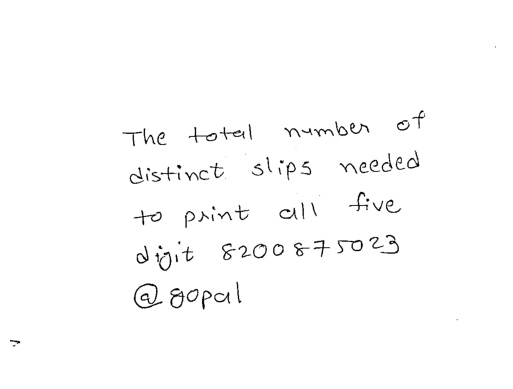

In [37]:

# Load image
image = Image.open("../photos/i4.jpeg").convert("RGB")

image = convert_image_to_black_and_white(image)


# Show black & white image
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()


In [38]:
lines = split_bw_image_into_valid_lines(image)

print("Lines with text:", len(lines))

Lines with text: 5


Lines detected: 5


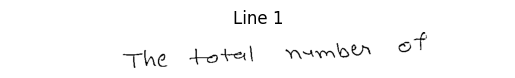

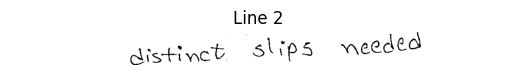

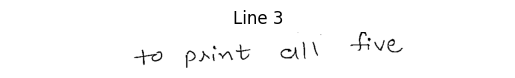

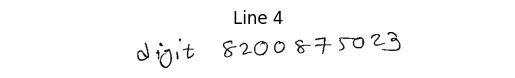

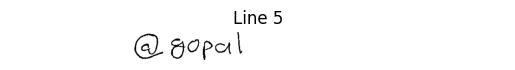

In [39]:

print("Lines detected:", len(lines))

for i, line in enumerate(lines):
    plt.imshow(line, cmap="gray")
    plt.axis("off")
    plt.title(f"Line {i+1}")
    plt.show()
